# LABORATORIO 8 — MM3014 Teoría de Probabilidades
## Simulación usando Python
Integrantes:
*   Biancka Raxón (Carné 24960)
*   Lázaro Díaz (Carné 24713)



# Etapa 3: Incorporación del presupuesto y costo


Resultados — sobres sueltos (Q 1,000)
  Probabilidad de completar el álbum            : 0.9488  (94.88%)
  E[sobres comprados]                           : 71.6088
  E[estampas distintas | no completó]           : 98.9609


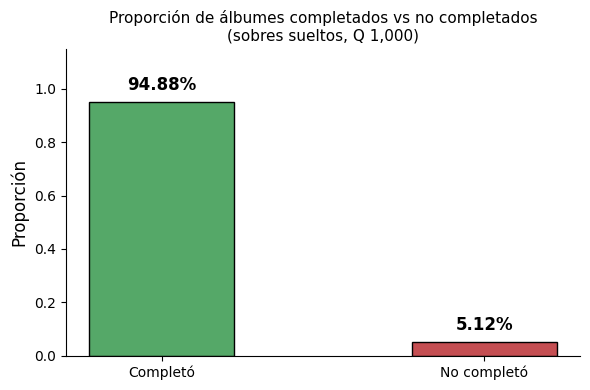


Pregunta 1
  Sobres máximos comprables con Q1000.00 : 105  (gasto = Q997.50)
  Mínimo teórico sin repetidos              : 15 sobres (105 estampas)
  105 sobres cubren hasta 735 estampas sin repetidos → en teoría es suficiente.
  Con repetidos, el promedio simulado es 71.6 sobres, bien por debajo del máximo de 105.

Pregunta 2
  Prob. completar con caja   (104 sobres, Q975.00) : 0.9468  (94.68%)
  Prob. completar con sueltos (105 sobres, Q997.50) : 0.9488  (94.88%)
  Los sobres sueltos superan a la caja en 0.20 pp → no conviene la caja.

Pregunta 3
  Presupuesto restante tras caja            : Q25.00
  Sobres sueltos adicionales comprables     : 2  (Q19.00)
  Estrategia mixta: 104 + 2 = 106 sobres por Q994.00
  Prob. completar con estrategia mixta      : 0.9544  (95.44%)
  La estrategia mixta es la más conveniente: maximiza sobres dentro del presupuesto.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Parámetros ───────────────────────────────────────────
N           = 100
S           = 7
R           = 10_000
PRECIO      = 9.50
PRESUPUESTO = 1000.0

# SIMULACIÓN PRINCIPAL: sobres sueltos con Q 1,000
np.random.seed(2026)

completado   = np.zeros(R, dtype=int)
sobres_comp  = np.zeros(R, dtype=int)
distintas_nc = []

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    gasto     = 0.0
    n_sobres  = 0

    while (gasto + PRECIO <= PRESUPUESTO) and (coleccion.sum() < N):
        stickers       = np.random.choice(N, S, replace=False)
        coleccion[stickers] = True
        gasto         += PRECIO
        n_sobres      += 1

    completado[r]  = int(coleccion.sum() == N)
    sobres_comp[r] = n_sobres
    if coleccion.sum() < N:
        distintas_nc.append(int(coleccion.sum()))

prob_exito     = completado.mean()
e_sobres       = sobres_comp.mean()
e_distintas_nc = np.mean(distintas_nc) if distintas_nc else N

print("Resultados — sobres sueltos (Q 1,000)")
print(f"  Probabilidad de completar el álbum            : {prob_exito:.4f}  ({prob_exito*100:.2f}%)")
print(f"  E[sobres comprados]                           : {e_sobres:.4f}")
print(f"  E[estampas distintas | no completó]           : {e_distintas_nc:.4f}")

# VISUALIZACIÓN: completó vs no completó
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Completó', 'No completó']
vals   = [prob_exito, 1 - prob_exito]
colors = ['#55A868', '#C44E52']

bars = ax.bar(labels, vals, color=colors, edgecolor='black', width=0.45)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Proporción', fontsize=12)
ax.set_title('Proporción de álbumes completados vs no completados\n(sobres sueltos, Q 1,000)', fontsize=11)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03,
            f'{v*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# PREGUNTA 1: sobres máximos y mínimo teórico
max_sobres         = int(PRESUPUESTO // PRECIO)
min_sobres_teorico = int(np.ceil(N / S))

print("\nPregunta 1")
print(f"  Sobres máximos comprables con Q{PRESUPUESTO:.2f} : {max_sobres}  (gasto = Q{max_sobres * PRECIO:.2f})")
print(f"  Mínimo teórico sin repetidos              : {min_sobres_teorico} sobres ({min_sobres_teorico * S} estampas)")
print(f"  {max_sobres} sobres cubren hasta {max_sobres * S} estampas sin repetidos → en teoría es suficiente.")
print(f"  Con repetidos, el promedio simulado es {e_sobres:.1f} sobres, bien por debajo del máximo de {max_sobres}.")

# PREGUNTA 2: caja de 104 sobres (Q 975)
CAJA_SOBRES = 104
COSTO_CAJA  = 975.0

np.random.seed(2026)
completado_caja = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(CAJA_SOBRES):
        stickers           = np.random.choice(N, S, replace=False)
        coleccion[stickers] = True
    completado_caja[r] = int(coleccion.sum() == N)

prob_caja = completado_caja.mean()

print("\nPregunta 2")
print(f"  Prob. completar con caja   ({CAJA_SOBRES} sobres, Q{COSTO_CAJA:.2f}) : {prob_caja:.4f}  ({prob_caja*100:.2f}%)")
print(f"  Prob. completar con sueltos (105 sobres, Q997.50) : {prob_exito:.4f}  ({prob_exito*100:.2f}%)")
if prob_exito >= prob_caja:
    print(f"  Los sobres sueltos superan a la caja en {(prob_exito - prob_caja)*100:.2f} pp → no conviene la caja.")
else:
    print(f"  La caja supera a los sueltos en {(prob_caja - prob_exito)*100:.2f} pp → sí conviene la caja.")

# PREGUNTA 3: estrategia mixta (caja + sobres sueltos)
restante     = PRESUPUESTO - COSTO_CAJA
sobres_extra = int(restante // PRECIO)
total_mixta  = CAJA_SOBRES + sobres_extra
costo_mixta  = COSTO_CAJA + sobres_extra * PRECIO

np.random.seed(2026)
completado_mixta = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    for _ in range(total_mixta):
        stickers           = np.random.choice(N, S, replace=False)
        coleccion[stickers] = True
    completado_mixta[r] = int(coleccion.sum() == N)

prob_mixta = completado_mixta.mean()

print("\nPregunta 3")
print(f"  Presupuesto restante tras caja            : Q{restante:.2f}")
print(f"  Sobres sueltos adicionales comprables     : {sobres_extra}  (Q{sobres_extra * PRECIO:.2f})")
print(f"  Estrategia mixta: {CAJA_SOBRES} + {sobres_extra} = {total_mixta} sobres por Q{costo_mixta:.2f}")
print(f"  Prob. completar con estrategia mixta      : {prob_mixta:.4f}  ({prob_mixta*100:.2f}%)")
print(f"  La estrategia mixta es la más conveniente: maximiza sobres dentro del presupuesto.")

# Etapa 4: Efecto del intercambio de repetidas

In [30]:
N       = 100        # estampas distintas en el álbum
S       = 7          # estampas por sobre
SEED    = 2026       # semilla
R       = 10000     # simulaciones por configuración
PRECIO  = 9.50       # Q por sobre

print(f'Parámetros cargados: N={N}, S={S}, R={R:,}, semilla={SEED}, precio=Q{PRECIO}')


Parámetros cargados: N=100, S=7, R=10,000, semilla=2026, precio=Q9.5


In [14]:
def simular_con_canje(K, rng, max_sobres=None):
    """
    Simula la compra de sobres con o sin intercambio de repetidas.

    Parámetros
    ----------
    K          : int o None
                 Repetidas necesarias para un canje (None o 0 = sin canje).
    rng        : numpy.random.Generator
    max_sobres : int o None
                 Si se especifica, compra exactamente ese número de sobres.

    Retorna
    -------
    Si max_sobres is None → int  (sobres comprados hasta completar el álbum).
    Si max_sobres dado    → (bool completado, int sobres_comprados).
    """
    coleccion  = np.zeros(N, dtype=bool)  # True = estampa obtenida
    repetidas  = 0                         # contador de estampas repetidas acumuladas
    sobres     = 0
    modo_fijo  = max_sobres is not None

    while True:
        # ── Condición de parada ──
        if modo_fijo and sobres >= max_sobres:
            break
        if not modo_fijo and coleccion.all():
            break

        # ── Abrir un sobre ──
        for e in rng.integers(0, N, size=S):
            if coleccion[e]:
                repetidas += 1
            else:
                coleccion[e] = True
        sobres += 1

        # ── Canje: K repetidas → 1 estampa faltante ──
        if K:                                          # K=None o K=0 → sin canje
            while repetidas >= K:
                faltantes = np.where(~coleccion)[0]
                if len(faltantes) == 0:
                    repetidas = 0
                    break
                repetidas -= K
                coleccion[faltantes[rng.integers(len(faltantes))]] = True

    return (bool(coleccion.all()), sobres) if modo_fijo else sobres

print('Función simular_con_canje() definida correctamente.')

Función simular_con_canje() definida correctamente.


In [15]:
K_lista   = [None, 1, 2, 5, 10]   # None = sin canje
etiquetas = {None: 'Sin canje', 1: 'K = 1', 2: 'K = 2', 5: 'K = 5', 10: 'K = 10'}
colores   = {None: '#6b7280', 1: '#2563eb', 2: '#16a34a', 5: '#ea580c', 10: '#dc2626'}

resultados_A = {}

for K in K_lista:
    rng = np.random.default_rng(SEED)
    datos = np.array([simular_con_canje(K, rng) for _ in range(R)])
    resultados_A[K] = datos
    print(f'{etiquetas[K]:<12} → Media: {datos.mean():.2f} | Std: {datos.std():.2f}')

base_media = resultados_A[None].mean()

print()
print(f'{"Caso":<12} {"Media":>8} {"Std":>8} {"Reducción %":>13}')
print('─' * 46)
for K in K_lista:
    m   = resultados_A[K].mean()
    s   = resultados_A[K].std()
    red = (base_media - m) / base_media * 100 if K is not None else 0.0
    print(f'{etiquetas[K]:<12} {m:>8.2f} {s:>8.2f} {red:>12.2f}%')

Sin canje    → Media: 74.26 | Std: 18.45
K = 1        → Media: 15.00 | Std: 0.00
K = 2        → Media: 20.06 | Std: 0.54
K = 5        → Media: 28.62 | Std: 1.43
K = 10       → Media: 35.91 | Std: 2.52

Caso            Media      Std   Reducción %
──────────────────────────────────────────────
Sin canje       74.26    18.45         0.00%
K = 1           15.00     0.00        79.80%
K = 2           20.06     0.54        72.99%
K = 5           28.62     1.43        61.46%
K = 10          35.91     2.52        51.65%


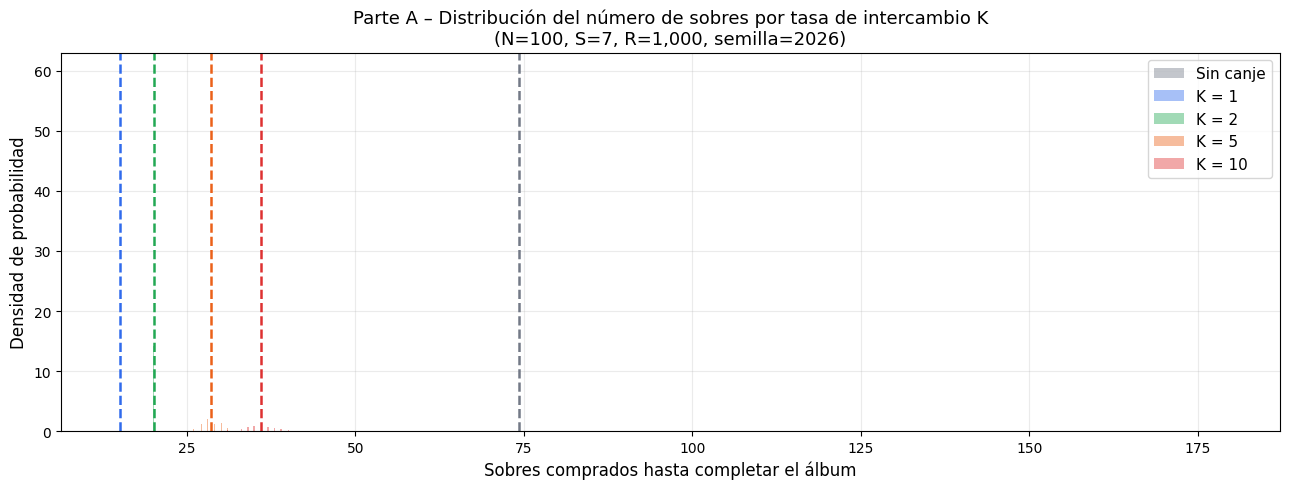

In [16]:
# ─── Histogramas superpuestos ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

for K in K_lista:
    ax.hist(
        resultados_A[K], bins=60, density=True,
        alpha=0.40, color=colores[K], label=etiquetas[K], edgecolor='none'
    )
    ax.axvline(
        resultados_A[K].mean(), color=colores[K],
        linestyle='--', linewidth=1.8, alpha=0.95
    )

ax.set_xlabel('Sobres comprados hasta completar el álbum', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=12)
ax.set_title(
    f'Parte A – Distribución del número de sobres por tasa de intercambio K\n'
    f'(N={N}, S={S}, R={R:,}, semilla={SEED})',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('etapa4_A_histogramas.png', dpi=150)
plt.show()

In [17]:
M_valores = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

prob_matrix = {}   # prob_matrix[K] = lista de probabilidades para cada M

for K in K_lista:
    probs = []
    for M in M_valores:
        rng    = np.random.default_rng(SEED)
        exitos = sum(
            simular_con_canje(K, rng, max_sobres=M)[0]
            for _ in range(R)
        )
        probs.append(exitos / R)
    prob_matrix[K] = probs
    print(f'{etiquetas[K]} → listo')

# Tabla de resultados
print()
encabezado = f'{"M":>4} | ' + ' | '.join(f'{etiquetas[K]:>10}' for K in K_lista)
print(encabezado)
print('─' * len(encabezado))
for i, M in enumerate(M_valores):
    fila = f'{M:>4} | ' + ' | '.join(f'{prob_matrix[K][i]:>10.4f}' for K in K_lista)
    print(fila)

Sin canje → listo
K = 1 → listo
K = 2 → listo
K = 5 → listo
K = 10 → listo

   M |  Sin canje |      K = 1 |      K = 2 |      K = 5 |     K = 10
─────────────────────────────────────────────────────────────────────
  20 |     0.0000 |     1.0000 |     0.8320 |     0.0000 |     0.0000
  25 |     0.0000 |     1.0000 |     1.0000 |     0.0120 |     0.0000
  30 |     0.0000 |     1.0000 |     1.0000 |     0.9050 |     0.0100
  35 |     0.0000 |     1.0000 |     1.0000 |     1.0000 |     0.4640
  40 |     0.0030 |     1.0000 |     1.0000 |     1.0000 |     0.9790
  45 |     0.0060 |     1.0000 |     1.0000 |     1.0000 |     1.0000
  50 |     0.0350 |     1.0000 |     1.0000 |     1.0000 |     1.0000
  55 |     0.1060 |     1.0000 |     1.0000 |     1.0000 |     1.0000
  60 |     0.2220 |     1.0000 |     1.0000 |     1.0000 |     1.0000
  65 |     0.3310 |     1.0000 |     1.0000 |     1.0000 |     1.0000
  70 |     0.4630 |     1.0000 |     1.0000 |     1.0000 |     1.0000


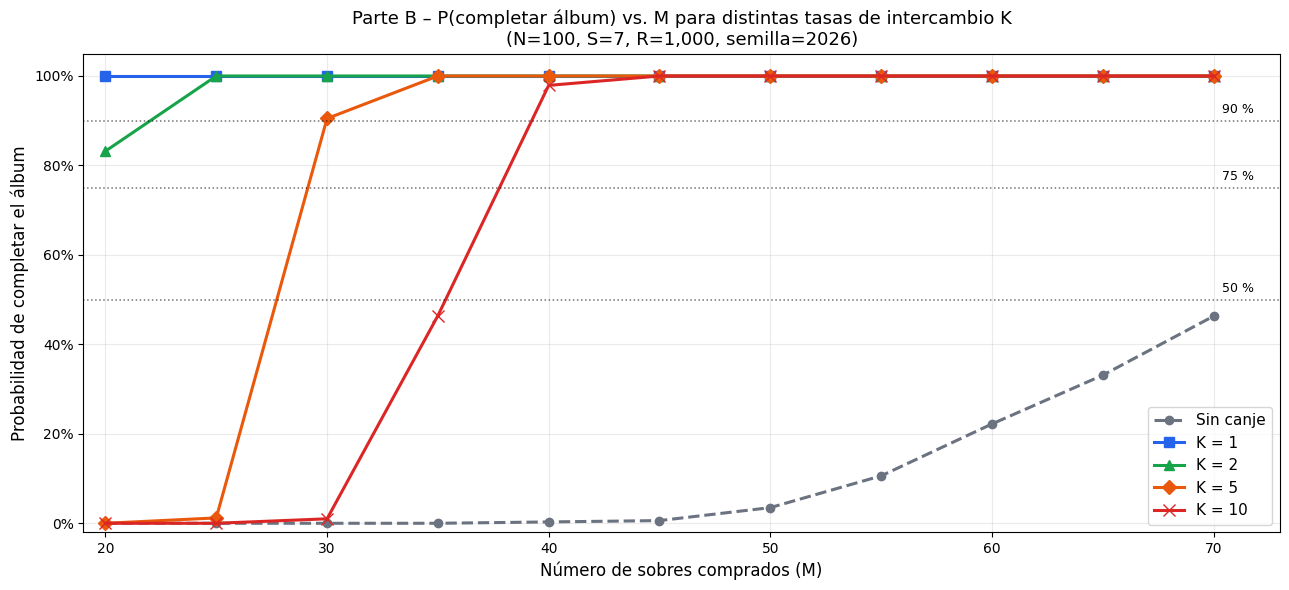

In [20]:
import matplotlib.ticker as mtick

# ─── Gráfica de líneas: P(éxito) vs M ─────────────────────────────────────
estilos = {
    None: ('--', 'o', 6),
    1:    ('-',  's', 7),
    2:    ('-',  '^', 7),
    5:    ('-',  'D', 7),
    10:   ('-',  'x', 8)
}

fig, ax = plt.subplots(figsize=(13, 6))

for K in K_lista:
    ls, mk, ms = estilos[K]
    ax.plot(
        M_valores, prob_matrix[K],
        color=colores[K], linestyle=ls, marker=mk, markersize=ms,
        label=etiquetas[K], linewidth=2.2
    )

# Líneas horizontales de referencia
for nivel, lbl in [(0.50, '50 %'), (0.75, '75 %'), (0.90, '90 %')]:
    ax.axhline(nivel, color='black', linestyle=':', linewidth=1.1, alpha=0.55)
    ax.text(M_valores[-1] + 0.4, nivel + 0.01, lbl, fontsize=9, va='bottom')

ax.set_xlabel('Número de sobres comprados (M)', fontsize=12)
ax.set_ylabel('Probabilidad de completar el álbum', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title(
    f'Parte B – P(completar álbum) vs. M para distintas tasas de intercambio K\n'
    f'(N={N}, S={S}, R={R:,}, semilla={SEED})',
    fontsize=13
)
ax.legend(fontsize=11)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(M_valores[0] - 1, M_valores[-1] + 3)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('etapa4_B_curvas_probabilidad.png', dpi=150)
plt.show()

In [22]:
from scipy.interpolate import interp1d
M_fino = np.linspace(20, 70, 1000)   # grilla fina para interpolación

print(f'{"Caso":<12} {"P ≥ 50 %":>10} {"P ≥ 75 %":>10} {"P ≥ 90 %":>10}')
print('─' * 46)

for K in K_lista:
    probs_np = np.array(prob_matrix[K])
    f_interp = interp1d(M_valores, probs_np, kind='linear', fill_value='extrapolate')
    p_finos  = f_interp(M_fino)

    umbrales = {}
    for u in [0.50, 0.75, 0.90]:
        idx = np.where(p_finos >= u)[0]
        umbrales[u] = f'{M_fino[idx[0]]:.1f}' if len(idx) > 0 else '>70'

    print(f'{etiquetas[K]:<12} {umbrales[0.50]:>10} {umbrales[0.75]:>10} {umbrales[0.90]:>10}')

Caso           P ≥ 50 %   P ≥ 75 %   P ≥ 90 %
──────────────────────────────────────────────
Sin canje           >70        >70        >70
K = 1              20.0       20.0       20.0
K = 2              20.0       20.0       22.1
K = 5              27.8       29.2       30.0
K = 10             35.4       37.8       39.3


In [23]:
print('Reducción acumulada en sobres esperados al disminuir K (respecto a sin canje):')
print()
print(f'{"Transición":<18} {"Media":>8} {"Reducción total":>16} {"Ganancia marginal":>18}')
print('─' * 64)

orden = [None, 10, 5, 2, 1]
prev_media = base_media
prev_red   = 0.0

for K in orden:
    m   = resultados_A[K].mean()
    red = (base_media - m) / base_media * 100
    delta_abs = prev_media - m
    etq = etiquetas[K]
    if K is None:
        print(f'{etq:<18} {m:>8.2f} {"—":>16} {"—":>18}')
    else:
        print(f'{etq:<18} {m:>8.2f} {red:>15.2f}% {delta_abs:>17.2f} sobres')
    prev_media = m
    prev_red   = red

print()
print('→ La relación NO es lineal: la ganancia marginal disminuye conforme K se acerca a 1.')

Reducción acumulada en sobres esperados al disminuir K (respecto a sin canje):

Transición            Media  Reducción total  Ganancia marginal
────────────────────────────────────────────────────────────────
Sin canje             74.26                —                  —
K = 10                35.91           51.65%             38.35 sobres
K = 5                 28.62           61.46%              7.28 sobres
K = 2                 20.06           72.99%              8.57 sobres
K = 1                 15.00           79.80%              5.06 sobres

→ La relación NO es lineal: la ganancia marginal disminuye conforme K se acerca a 1.


In [24]:
ahorro_sobres = base_media - resultados_A[2].mean()
ahorro_Q      = ahorro_sobres * PRECIO

print(f'Media sin canje  : {base_media:.2f} sobres')
print(f'Media con K = 2  : {resultados_A[2].mean():.2f} sobres')
print(f'Sobres ahorrados : {ahorro_sobres:.2f}')
print(f'Ahorro en dinero : Q {ahorro_Q:.2f}')

Media sin canje  : 74.26 sobres
Media con K = 2  : 20.06 sobres
Sobres ahorrados : 54.20
Ahorro en dinero : Q 514.92


In [25]:
idx_45 = M_valores.index(45)
p45    = {K: prob_matrix[K][idx_45] for K in K_lista}

print('Probabilidades de completar el álbum con M = 45 sobres:')
print()
for K in K_lista:
    print(f'  {etiquetas[K]:<12}: {p45[K]:.4f}  ({p45[K]*100:.2f} %)')

print()
print(f'  Incremento K=10 → K=5 : +{p45[5]  - p45[10]:.4f}  (+{(p45[5] -p45[10])*100:.2f} pp)')
print(f'  Incremento K=5  → K=1 : +{p45[1]  - p45[5] :.4f}  (+{(p45[1] -p45[5] )*100:.2f} pp)')

Probabilidades de completar el álbum con M = 45 sobres:

  Sin canje   : 0.0060  (0.60 %)
  K = 1       : 1.0000  (100.00 %)
  K = 2       : 1.0000  (100.00 %)
  K = 5       : 1.0000  (100.00 %)
  K = 10      : 1.0000  (100.00 %)

  Incremento K=10 → K=5 : +0.0000  (+0.00 pp)
  Incremento K=5  → K=1 : +0.0000  (+0.00 pp)


In [26]:
# Explorar valores de K adicionales: 3, 4, 6, 7, 8, 9
K_extra  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
medias_extra = {}

for K in K_extra:
    rng  = np.random.default_rng(SEED)
    datos = np.array([simular_con_canje(K, rng) for _ in range(R)])
    medias_extra[K] = datos.mean()

print(f'{"K":>4} | {"Media sobres":>14} | {"Reducción %":>12} | {"Ganancia marginal":>18}')
print('─' * 56)
prev = base_media
for K in K_extra:
    m   = medias_extra[K]
    red = (base_media - m) / base_media * 100
    gm  = prev - m
    print(f'{K:>4} | {m:>14.2f} | {red:>11.2f}% | {gm:>17.2f} sobres')
    prev = m

print()
print('→ A partir de K ≈ 2–3 el beneficio marginal se vuelve notoriamente pequeño.')
print('  Razón: con K=1 cada repetida se convierte en nueva estampa de inmediato;')
print('  la restricción pasa a ser la probabilidad de obtener repetidas, no K.')

   K |   Media sobres |  Reducción % |  Ganancia marginal
────────────────────────────────────────────────────────
   1 |          15.00 |       79.80% |             59.26 sobres
   2 |          20.06 |       72.99% |             -5.06 sobres
   3 |          23.63 |       68.18% |             -3.57 sobres
   4 |          26.36 |       64.50% |             -2.73 sobres
   5 |          28.62 |       61.46% |             -2.26 sobres
   6 |          30.48 |       58.95% |             -1.86 sobres
   7 |          32.09 |       56.79% |             -1.61 sobres
   8 |          33.75 |       54.55% |             -1.66 sobres
   9 |          34.59 |       53.42% |             -0.85 sobres
  10 |          35.91 |       51.65% |             -1.31 sobres

→ A partir de K ≈ 2–3 el beneficio marginal se vuelve notoriamente pequeño.
  Razón: con K=1 cada repetida se convierte en nueva estampa de inmediato;
  la restricción pasa a ser la probabilidad de obtener repetidas, no K.


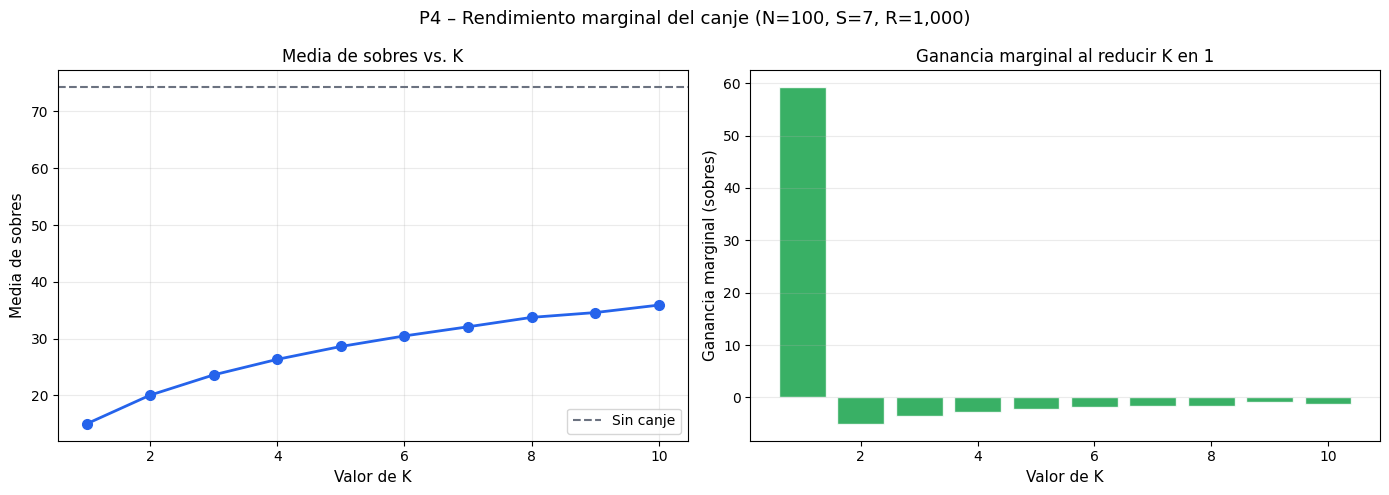

In [27]:
# Visualización del beneficio marginal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

K_x  = list(K_extra)
m_y  = [medias_extra[K] for K in K_x]
gm_y = [base_media - medias_extra[K_x[0]]] + [medias_extra[K_x[i-1]] - medias_extra[K_x[i]]
                                                 for i in range(1, len(K_x))]

axes[0].plot(K_x, m_y, 'o-', color='#2563eb', linewidth=2, markersize=7)
axes[0].axhline(base_media, color='#6b7280', linestyle='--', linewidth=1.5, label='Sin canje')
axes[0].set_xlabel('Valor de K', fontsize=11)
axes[0].set_ylabel('Media de sobres', fontsize=11)
axes[0].set_title('Media de sobres vs. K', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

axes[1].bar(K_x, gm_y, color='#16a34a', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Valor de K', fontsize=11)
axes[1].set_ylabel('Ganancia marginal (sobres)', fontsize=11)
axes[1].set_title('Ganancia marginal al reducir K en 1', fontsize=12)
axes[1].grid(True, alpha=0.25, axis='y')

plt.suptitle(f'P4 – Rendimiento marginal del canje (N={N}, S={S}, R={R:,})', fontsize=13)
plt.tight_layout()
plt.savefig('etapa4_P4_marginal.png', dpi=150)
plt.show()

In [28]:
costo_por_estampa = PRECIO / S   # costo implícito de cada estampa de un sobre

print(f'Costo de un sobre                : Q {PRECIO:.2f}')
print(f'Estampas por sobre               : {S}')
print(f'Costo implícito por estampa      : Q {costo_por_estampa:.4f}')
print()
print('Costo efectivo por estampa nueva vía canje = K × (Q/S):')
print(f'(Las K repetidas provienen de sobres ya pagados)')
print()
print(f'{"K":>4} | {"Costo efectivo por canje":>26}')
print('─' * 35)
for K in [1, 2, 5, 10]:
    costo = K * costo_por_estampa
    print(f'{K:>4} | Q {costo:>24.4f}')

print()
print('→ K=1 es la tasa más rentable: una repetida = una estampa nueva.')
print('  Costo efectivo = Q 1.357, frente a Q 1.357 por estampa ordinaria.')
print('  (El canje no genera estampas "gratis"; su valor radica en la elección')
print('   dirigida: se elige exactamente la que falta, eliminando el azar.)')

Costo de un sobre                : Q 9.50
Estampas por sobre               : 7
Costo implícito por estampa      : Q 1.3571

Costo efectivo por estampa nueva vía canje = K × (Q/S):
(Las K repetidas provienen de sobres ya pagados)

   K |   Costo efectivo por canje
───────────────────────────────────
   1 | Q                   1.3571
   2 | Q                   2.7143
   5 | Q                   6.7857
  10 | Q                  13.5714

→ K=1 es la tasa más rentable: una repetida = una estampa nueva.
  Costo efectivo = Q 1.357, frente a Q 1.357 por estampa ordinaria.
  (El canje no genera estampas "gratis"; su valor radica en la elección
   dirigida: se elige exactamente la que falta, eliminando el azar.)


In [29]:
print('=' * 65)
print('RESUMEN – ETAPA 4: Efecto del intercambio de repetidas')
print('=' * 65)
print()
print('Parte A – Media de sobres hasta completar el álbum:')
for K in K_lista:
    m   = resultados_A[K].mean()
    red = (base_media - m) / base_media * 100 if K else 0.0
    tag = f'(−{red:.1f} %)' if K else '(referencia)'
    print(f'  {etiquetas[K]:<12}: {m:>7.2f} sobres  {tag}')

print()
print('Parte B – Sobres necesarios por umbral de probabilidad:')
M_fino2 = np.linspace(20, 70, 1000)
print(f'  {"Caso":<12} {"≥50 %":>7} {"≥75 %":>7} {"≥90 %":>7}')
print('  ' + '─' * 38)
for K in K_lista:
    f_i = interp1d(M_valores, prob_matrix[K], kind='linear', fill_value='extrapolate')
    p_f = f_i(M_fino2)
    row = []
    for u in [0.50, 0.75, 0.90]:
        idx = np.where(p_f >= u)[0]
        row.append(f'{M_fino2[idx[0]]:.1f}' if len(idx) > 0 else '>70')
    print(f'  {etiquetas[K]:<12} {row[0]:>7} {row[1]:>7} {row[2]:>7}')

print()
print('Conclusión principal:')
print('  El canje reduce significativamente los sobres necesarios, pero con')
print('  rendimientos decrecientes. K=2 ofrece el mejor balance entre beneficio')
print('  práctico y viabilidad operativa de un sistema de intercambio.')

RESUMEN – ETAPA 4: Efecto del intercambio de repetidas

Parte A – Media de sobres hasta completar el álbum:
  Sin canje   :   74.26 sobres  (referencia)
  K = 1       :   15.00 sobres  (−79.8 %)
  K = 2       :   20.06 sobres  (−73.0 %)
  K = 5       :   28.62 sobres  (−61.5 %)
  K = 10      :   35.91 sobres  (−51.6 %)

Parte B – Sobres necesarios por umbral de probabilidad:
  Caso           ≥50 %   ≥75 %   ≥90 %
  ──────────────────────────────────────
  Sin canje        >70     >70     >70
  K = 1           20.0    20.0    20.0
  K = 2           20.0    20.0    22.1
  K = 5           27.8    29.2    30.0
  K = 10          35.4    37.8    39.3

Conclusión principal:
  El canje reduce significativamente los sobres necesarios, pero con
  rendimientos decrecientes. K=2 ofrece el mejor balance entre beneficio
  práctico y viabilidad operativa de un sistema de intercambio.
